In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
# Load Titanic dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Shape of Dataset:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Missing Values in Dataset:\n")

df.isnull().sum()

Missing Values in Dataset:



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Fill missing Age values with median

df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
# Fill missing Embarked values with mode

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
# Replace missing Cabin values

df['Cabin'] = df['Cabin'].fillna("Unknown")

In [10]:
print("Missing Values After Cleaning:\n")

df.isnull().sum()

Missing Values After Cleaning:



PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [11]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
survival_rate = df['Survived'].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


In [ ]:
#Question 1: Who Survived More - Male or Female?
#Analysis
gender_survival = pd.crosstab(df['Sex'], df['Survived'])

gender_survival

Survived,0,1
Sex,,
female,81,233
male,468,109


In [14]:
gender_rate = df.groupby('Sex')['Survived'].mean() * 100

gender_rate

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

C:\Users\Ram\AppData\Local\Temp\ipykernel_21200\8382549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


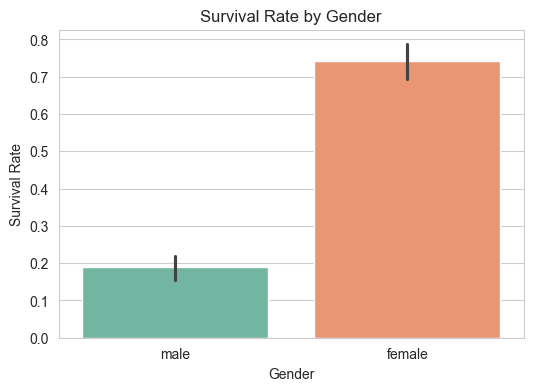

In [ ]:
#Visualization
plt.figure(figsize=(6,4))

sns.barplot(
    x='Sex',
    y='Survived',
    data=df,
    palette='Set2'
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

In [17]:
#Question 2: Did Passenger Class Affect Survival?
#Analysis
class_survival = df.groupby('Pclass')['Survived'].mean() * 100

class_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

C:\Users\Ram\AppData\Local\Temp\ipykernel_21200\3210995380.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


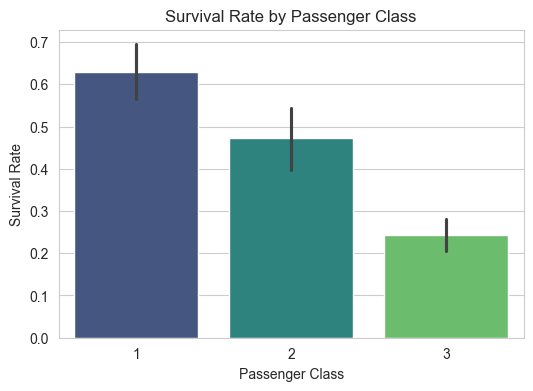

In [18]:
#Visualization
plt.figure(figsize=(6,4))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df,
    palette='viridis'
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [19]:
#Question 3: Survival Rate by Age Group
bins = [0, 12, 18, 35, 60, 100]

labels = [
    'Child',
    'Teenager',
    'Young Adult',
    'Adult',
    'Senior'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [21]:
#Analysis
age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100

age_survival

C:\Users\Ram\AppData\Local\Temp\ipykernel_21200\168514092.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100


AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

C:\Users\Ram\AppData\Local\Temp\ipykernel_21200\4044405562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


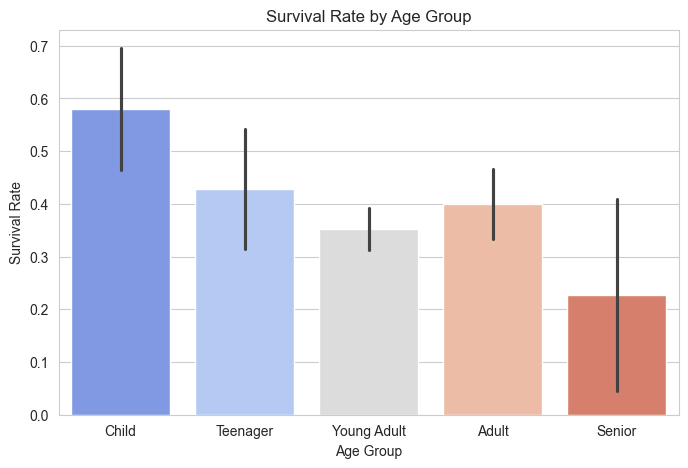

In [22]:
#Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x='AgeGroup',
    y='Survived',
    data=df,
    palette='coolwarm'
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

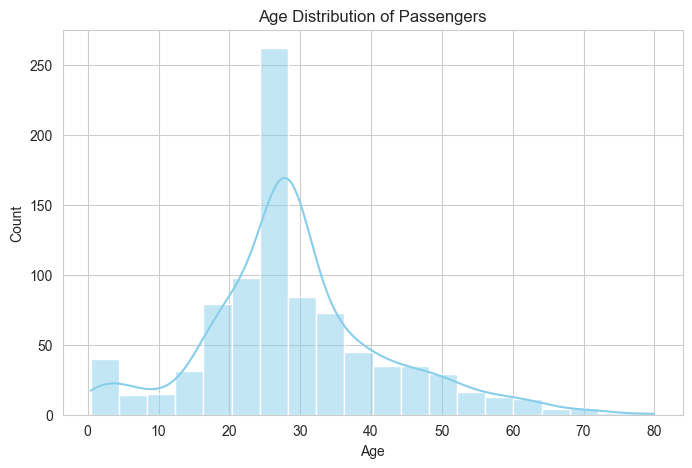

In [23]:
#Visualization - Histogram of Passenger Ages
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

C:\Users\Ram\AppData\Local\Temp\ipykernel_21200\1577144974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


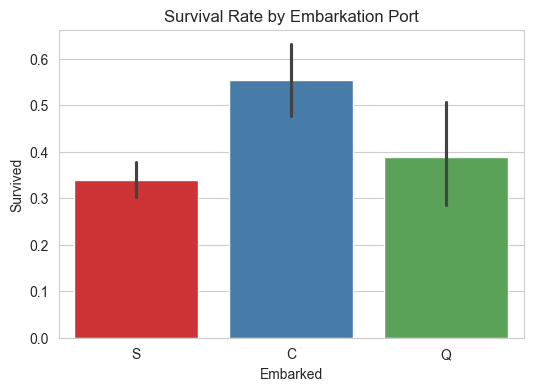

In [24]:
#Visualization - Survival by Embarked Port
plt.figure(figsize=(6,4))

sns.barplot(
    x='Embarked',
    y='Survived',
    data=df,
    palette='Set1'
)

plt.title("Survival Rate by Embarkation Port")

plt.show()

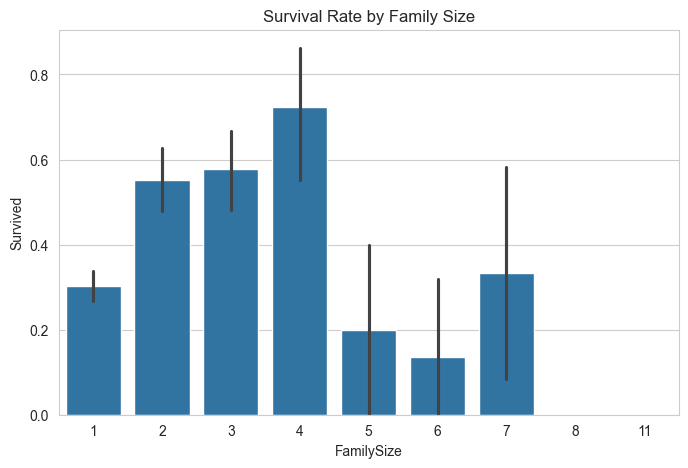

In [25]:
#Visualization - Survival by Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(8,5))

sns.barplot(
    x='FamilySize',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Family Size")

plt.show()

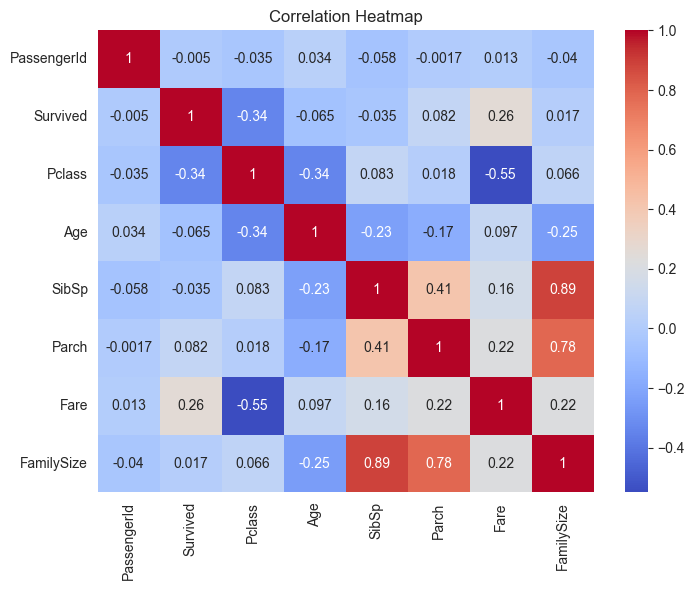

In [26]:
#Visualization - Correlation Heatmap
plt.figure(figsize=(8,6))

numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [31]:
#Conculsions:
# After analyzing the Titanic dataset, the following conclusions were observed:
print("1. Gender Impact")
print("Female passengers had a much higher survival rate than males.\n")

print("2. Passenger Class Impact")
print("Passenger class significantly affected survival chances.")
print("First-class passengers were more likely to survive than third-class passengers.\n")

print("3. Age Impact")
print("Children generally had better survival rates than adults and seniors.\n")

print("4. Age Distribution")
print("Most passengers were young adults between 20 and 40 years old.")

print("5. Data Cleaning")
print("Missing values in Age, Cabin, and Embarked columns were successfully handled before analysisn\n")  

print("6. Overall Finding")
print("The most important factors affecting survival were:")
print("- Gender")
print("- Passenger Class")
print("- Age")

#These findings demonstrate how data analysis can be used to answer real-world questions and uncover meaningful patterns.

1. Gender Impact
Female passengers had a much higher survival rate than males.

2. Passenger Class Impact
Passenger class significantly affected survival chances.
First-class passengers were more likely to survive than third-class passengers.

3. Age Impact
Children generally had better survival rates than adults and seniors.

4. Age Distribution
Most passengers were young adults between 20 and 40 years old.
5. Data Cleaning
Missing values in Age, Cabin, and Embarked columns were successfully handled before analysisn

6. Overall Finding
The most important factors affecting survival were:
- Gender
- Passenger Class
- Age
